<a href="https://colab.research.google.com/github/tungcheese/DEEPLEARNING/blob/main/test/test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

In [2]:
# Cài thư viện
!pip install gdown

In [11]:
import gdown

# Download toàn bộ folder
url = "https://drive.google.com/drive/folders/16JkjeEsymg-stXrbprundTFEB7uQtjp5"

gdown.download_folder(url, quiet=False, use_cookies=False, remaining_ok=True)

Retrieving folder contents


Retrieving folder 1A0IFmmerrFYllL67E588QvIgi2h961Qd train
Retrieving folder 1Mkta8jUFpRpvj9NY-HWIRcq3nn8MUAwJ bird
Processing file 1U7tlz6AaZrFkHGSysnWKW2xHwhA4ky_H train_0001.jpg
Processing file 1mx9QME76v67aXmjnj9zsBsGeJo2SevXg train_0002.jpg
Processing file 13PbUeQujZyPbeORTN0k_CVehkSt4C_gw train_0003.jpg
Processing file 1g4vuLHsyne60Yvv0EKci_2EMu3XurTsO train_0004.jpg
Processing file 1Ns6AWEidkVtT3HLmw1mA0szqj1wbc39m train_0005.jpg
Processing file 1OLShC4wtbd9KfammttThLt-EDlaWKZPj train_0006.jpg
Processing file 1QMKfrMJtnRibdcDRKIiVa4wMgKZdw6sK train_0007.jpg
Processing file 1NB-Nz3S1lGJkuavexBb5Iaq0jRPRgq8k train_0008.jpg
Processing file 1mEZ0oM6m0ZvTEQ732dDo-4LDokTln7-1 train_0009.jpg
Processing file 1xN5K3vb10Y5xfmPeUmwYZ9SJ7RpTmEDn train_0010.jpg
Processing file 1KD57jdAyZ7jBWaKqx367SW3WbsfH3jOu train_0011.jpg
Processing file 1NAeig7qe8ClXf7rMBoD8VrJJkzEoqqqf train_0012.jpg
Processing file 1DQSShVtEjvRBMJfwWybyE0aN-YcA4AH5 train_0013.jpg
Processing file 12lCIPRE3azdcPUGaVcdYMG_

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1U7tlz6AaZrFkHGSysnWKW2xHwhA4ky_H
To: /content/Datasets-for-DL-Group05/train/bird/train_0001.jpg
100%|██████████| 118k/118k [00:00<00:00, 4.08MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mx9QME76v67aXmjnj9zsBsGeJo2SevXg
To: /content/Datasets-for-DL-Group05/train/bird/train_0002.jpg
100%|██████████| 99.9k/99.9k [00:00<00:00, 2.40MB/s]
Downloading...
From: https://drive.google.com/uc?id=13PbUeQujZyPbeORTN0k_CVehkSt4C_gw
To: /content/Datasets-for-DL-Group05/train/bird/train_0003.jpg
100%|██████████| 141k/141k [00:00<00:00, 3.79MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g4vuLHsyne60Yvv0EKci_2EMu3XurTsO
To: /content/Datasets-for-DL-Group05/train/bird/train_0004.jpg
100%|██████████| 78.5k/78.5k [00:00<00:00, 2.21MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ns6AWEidkVtT3HLmw1mA0szqj1wbc39m
To: /

FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1IduBVRQIZiH1vXHn23gS2LN9uunC6OsU

but Gdown can't. Please check connections and permissions.

The previous `gdown.download_folder` command failed because the folder contains more than 50 files. To download a folder with many files, we can use `PyDrive` to interact with Google Drive's API. This allows us to authenticate and then iterate through the files within the specified folder, downloading them one by one.

In [6]:
# Install PyDrive2
!pip install -U -q PyDrive2

In [12]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
import os
from google.colab import auth
from oauth2client.client import GoogleCredentials # Import to get application default credentials

# 1. Authenticate and create the PyDrive client.
# This will prompt you to open a URL, sign in, and paste the authorization code.
auth.authenticate_user()

gauth = GoogleAuth()
# Set credentials from the authenticated Colab session
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Replace with the actual Google Drive Folder ID
# The folder ID is the part after 'folders/' in your URL
# For 'https://drive.google.com/drive/folders/16JkjeEsymg-stXrbprundTFEB7uQtjp5'
# The folder ID is '16JkjeEsymg-stXrbprundTFEB7uQtjp5'
folder_id = '16JkjeEsymg-stXrbprundTFEB7uQtjp5'

# Create a directory to save the downloaded files
output_dir = 'dataset'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Function to download files from a Google Drive folder recursively
def download_folder_contents(folder_id, destination_path):
    file_list = drive.ListFile({'q': f"'{folder_id}' in parents and trashed=false"}).GetList()
    for file_obj in file_list:
        file_path = os.path.join(destination_path, file_obj['title'])
        if file_obj['mimeType'] == 'application/vnd.google-apps.folder':
            # If it's a folder, create the directory and recurse
            os.makedirs(file_path, exist_ok=True)
            print(f"Created directory: {file_path}")
            download_folder_contents(file_obj['id'], file_path)
        else:
            # If it's a file, download it
            print(f"Downloading '{file_obj['title']}' to {file_path}")
            file_obj.GetContentFile(file_path)

# Start downloading the contents of the main folder
# This will create a 'dataset' folder in your Colab environment
download_folder_contents(folder_id, output_dir)

print("Download complete!")

Created directory: dataset/train
Created directory: dataset/train/fish
Created directory: dataset/train/dog
Created directory: dataset/train/cat
Created directory: dataset/train/bird
Created directory: dataset/train/flower
Created directory: dataset/var
Created directory: dataset/var/bird
Created directory: dataset/var/flower
Created directory: dataset/var/fish
Created directory: dataset/var/cat
Created directory: dataset/var/dog
Download complete!


In [13]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%matplotlib inline


In [15]:
class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, channels):
        super().__init__()
        hidden = max(1, channels // 16)
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels)
        )

    def forward(self, x):
        squeeze = F.avg_pool2d(x, (x.size(2), x.size(3)))
        att = self.mlp(squeeze)
        scale = torch.sigmoid(att).unsqueeze(2).unsqueeze(3)
        return x * scale

class SE(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.cg = ChannelGate(channels)

    def forward(self, x):
        return self.cg(x)


class modulePDP(nn.Module):
    def __init__(self, in_channels, out_channels, s):
        super().__init__()

        self.pw1 = nn.Conv2d(in_channels, in_channels, 1)
        self.dw = nn.Conv2d(in_channels, in_channels, 3, stride=s, padding=1, groups=in_channels)
        self.pw2 = nn.Conv2d(in_channels, out_channels, 1)

        self.se = SE(out_channels)
        self.pwr = nn.Conv2d(in_channels, out_channels, 1, stride=s)

        self.s = s

    def forward(self, x):
        out = F.relu(self.pw1(x))
        out = F.relu(self.dw(out))
        out = F.relu(self.pw2(out))
        out = self.se(out)

        if self.s == 1 and x.size() == out.size():
            out = x + out
        else:
            out = F.relu(self.pwr(x)) + out

        return F.relu(out)


class M1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        self.block1 = modulePDP(32, 64, 2)
        self.block2 = modulePDP(64, 128, 2)
        self.block3 = modulePDP(128, 128, 1)

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        return self.fc(x)

In [16]:
def get_loader(img_size):

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

    base_path = "/content/dataset"

    train_set = datasets.ImageFolder(base_path + "/train", transform=transform)
    var_set  = datasets.ImageFolder(base_path + "/var", transform=transform)

    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    var_loader  = DataLoader(var_set, batch_size=32, shuffle=False)

    return train_loader, var_loader, len(train_set.classes)

In [20]:
def train_model(img_size):

    train_loader, var_loader, num_classes = get_loader(img_size)

    model = M1(num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc_list, var_acc_list = [], []
    train_loss_list, var_loss_list = [], []

    for epoch in range(1, 101):

        # TRAIN
        model.train()
        train_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()

        train_acc = 100 * correct / total

        # TEST
        model.eval()
        var_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for x, y in var_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                loss = criterion(out, y)

                var_loss += loss.item()
                _, pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()

        var_acc = 100 * correct / total

        train_acc_list.append(train_acc)
        var_acc_list.append(var_acc) # Changed from test_acc to var_acc
        train_loss_list.append(train_loss)
        var_loss_list.append(var_loss) # Changed from test_loss to var_loss

        print(f"Epoch {epoch:03d} | Train Acc: {train_acc:.2f}% | Test Acc: {var_acc:.2f}%")

    return train_acc_list, var_acc_list, train_loss_list, var_loss_list

In [21]:
def plot_results(train_acc, var_acc, train_loss, var_loss, title):

    epochs = range(1, len(train_acc) + 1)

    plt.figure()

    plt.plot(epochs, train_acc, label='Train Acc')
    plt.plot(epochs, var_acc, label='Test Acc')
    plt.title("Accuracy - " + title)
    plt.legend()
    plt.show()

    plt.figure()

    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, var_loss, label='Test Loss')
    plt.title("Loss - " + title)
    plt.legend()
    plt.show()

Epoch 001 | Train Acc: 24.32% | Test Acc: 20.40%
Epoch 002 | Train Acc: 29.92% | Test Acc: 22.80%
Epoch 003 | Train Acc: 32.88% | Test Acc: 23.60%
Epoch 004 | Train Acc: 34.64% | Test Acc: 27.20%
Epoch 005 | Train Acc: 40.16% | Test Acc: 34.40%
Epoch 006 | Train Acc: 40.60% | Test Acc: 28.80%
Epoch 007 | Train Acc: 43.08% | Test Acc: 29.60%
Epoch 008 | Train Acc: 43.04% | Test Acc: 40.00%
Epoch 009 | Train Acc: 45.40% | Test Acc: 38.00%
Epoch 010 | Train Acc: 46.52% | Test Acc: 35.20%
Epoch 011 | Train Acc: 49.44% | Test Acc: 36.00%
Epoch 012 | Train Acc: 52.56% | Test Acc: 36.40%
Epoch 013 | Train Acc: 53.28% | Test Acc: 32.40%
Epoch 014 | Train Acc: 53.44% | Test Acc: 35.60%
Epoch 015 | Train Acc: 55.36% | Test Acc: 37.60%
Epoch 016 | Train Acc: 57.64% | Test Acc: 40.80%
Epoch 017 | Train Acc: 57.28% | Test Acc: 38.00%
Epoch 018 | Train Acc: 57.80% | Test Acc: 46.40%
Epoch 019 | Train Acc: 57.96% | Test Acc: 43.20%
Epoch 020 | Train Acc: 58.84% | Test Acc: 41.60%
Epoch 021 | Train Ac

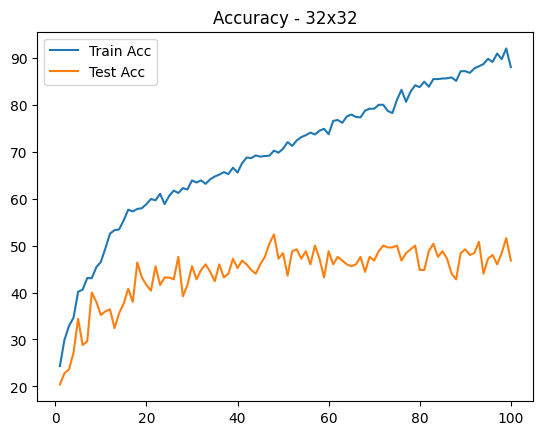

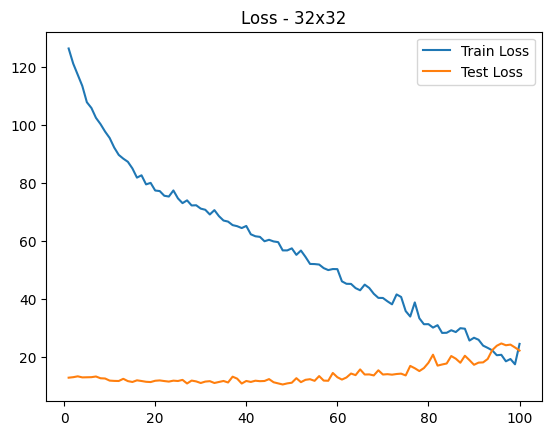

In [22]:
train_acc, var_acc, train_loss, var_loss = train_model(32)
plot_results(train_acc, var_acc, train_loss, var_loss, "32x32")